In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("anime.csv")
df

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
...,...,...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [5]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [6]:
df.isnull().sum()

,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0


In [7]:
df["genre"].mode()

,genre
0,Hentai


In [8]:
df["genre"]=df["genre"].fillna(df["type"].mode()[0])
df["type"]=df["type"].fillna(df["type"].mode()[0])
df["rating"]=df["rating"].fillna(0)
df.isnull().sum()

,0
anime_id,0
name,0
genre,0
type,0
episodes,0
rating,0
members,0


In [9]:
df.groupby('name')['rating'].mean().sort_values(ascending=False).head()

,rating
name,
Taka no Tsume 8: Yoshida-kun no X-Files,10.00
Spoon-hime no Swing Kitchen,9.60
Mogura no Motoro,9.50
Kimi no Na wa.,9.37
Kahei no Umi,9.33


In [10]:
df.groupby('name')['rating'].count().sort_values(ascending=False).head(10)

,rating
name,
Shi Wan Ge Leng Xiaohua,2
Saru Kani Gassen,2
Otome Hime,1
Otome Juurin Yuugi: Maiden Infringement Play,1
Otome Nadeshiko Koi Techou,1
Otome Youkai Zakuro,1
Otome Youkai Zakuro Picture Drama,1
Otome wa Boku ni Koishiteru,1
Otome wa Boku ni Koishiteru Special,1


In [11]:
rating = pd.DataFrame(df.groupby('name')['rating'].mean())
rating.head()

,rating
name,
&quot;0&quot;,5.06
"&quot;Aesop&quot; no Ohanashi yori: Ushi to Kaeru, Yokubatta Inu",5.00
&quot;Bungaku Shoujo&quot; Kyou no Oyatsu: Hatsukoi,7.06
&quot;Bungaku Shoujo&quot; Memoire,7.54
&quot;Bungaku Shoujo&quot; Movie,7.63


In [12]:
rating['num of ratings'] = pd.DataFrame(df.groupby('name')['rating'].count())
rating.head()

,rating,num of ratings
name,,
&quot;0&quot;,5.06,1
"&quot;Aesop&quot; no Ohanashi yori: Ushi to Kaeru, Yokubatta Inu",5.00,1
&quot;Bungaku Shoujo&quot; Kyou no Oyatsu: Hatsukoi,7.06,1
&quot;Bungaku Shoujo&quot; Memoire,7.54,1
&quot;Bungaku Shoujo&quot; Movie,7.63,1


In [13]:
# Data visualization

<Axes: >

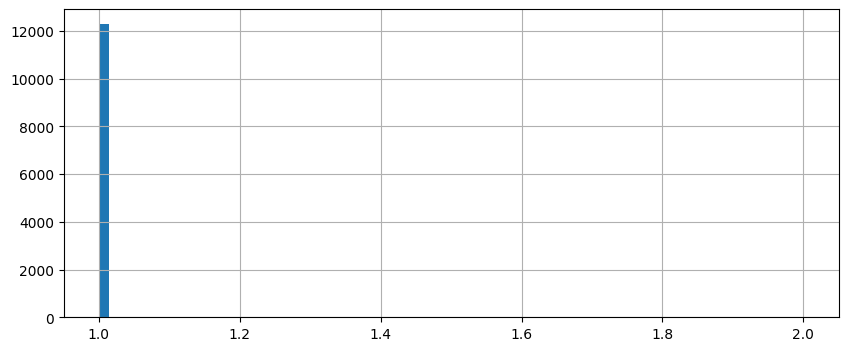

In [14]:
plt.figure(figsize=(10,4))
rating['num of ratings'].hist(bins=70)



<Axes: >

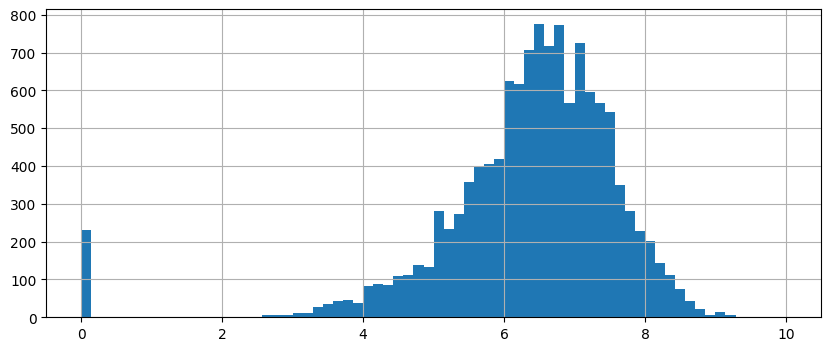

In [15]:
plt.figure(figsize=(10,4))
rating['rating'].hist(bins=70)

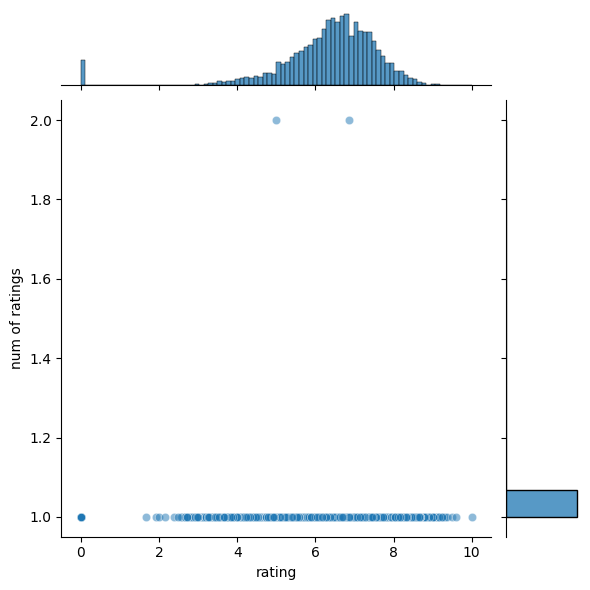

In [16]:
sns.jointplot(x='rating',y='num of ratings',data=rating,alpha=0.5)

Text(0.5, 1.0, 'Ratings Frequency')

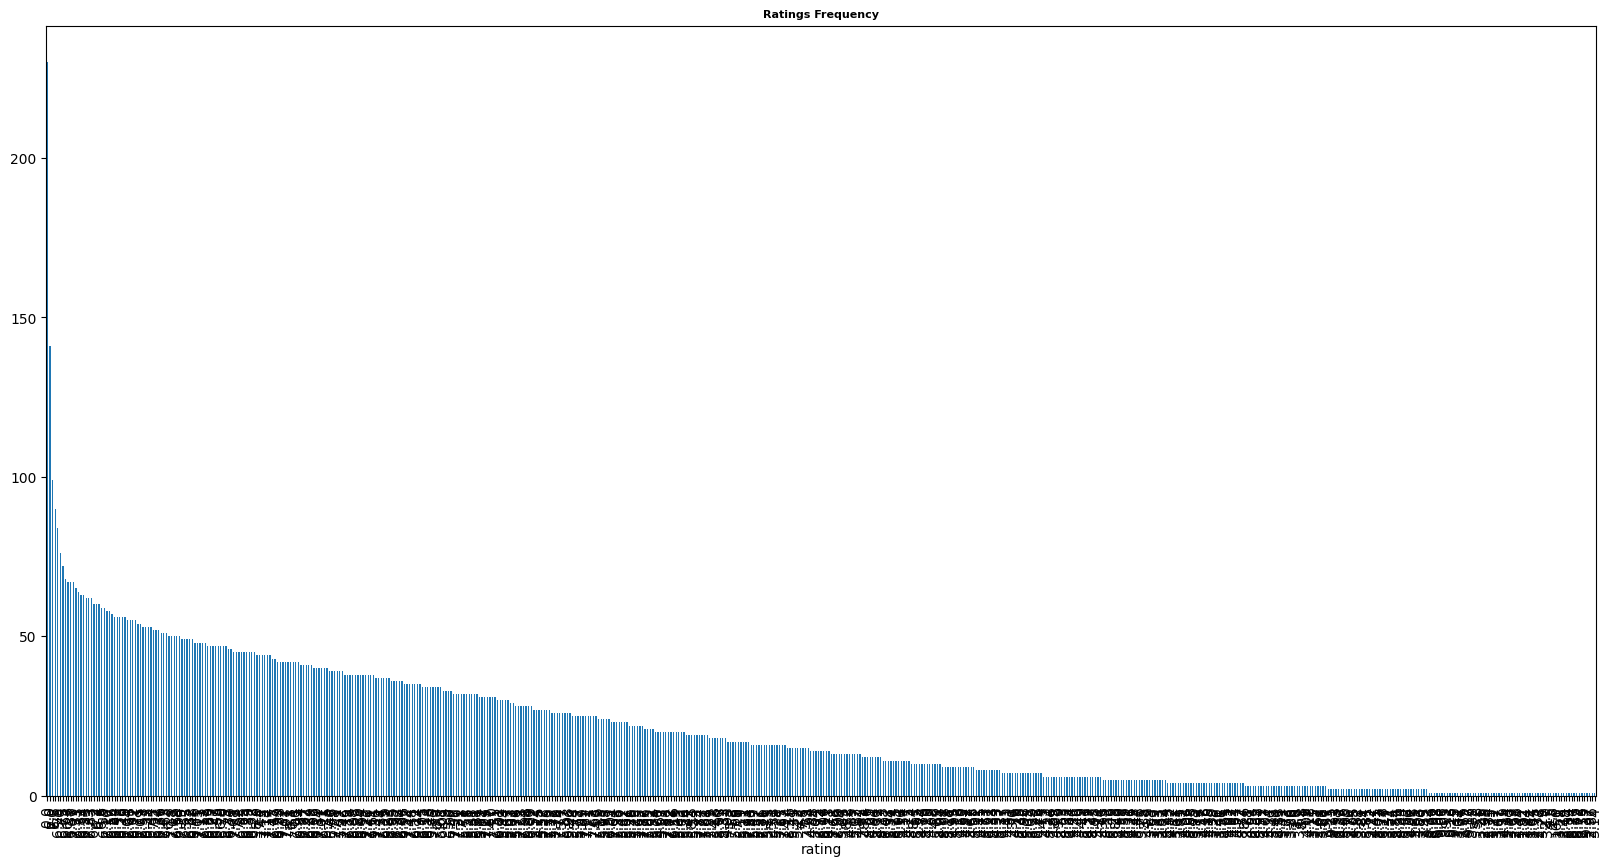

In [17]:
plt.figure(figsize=(20,10))
df['rating'].value_counts().plot(kind='bar')
plt.title('Ratings Frequency', fontsize = 8, fontweight = 'bold')

In [18]:
top_anime = df[['rating', 'name']].value_counts().head(10)
top_anime.index

MultiIndex([(10.0, 'Taka no Tsume 8: Yoshida-kun no X-Files'),
            ( 0.0,               '6HP (Six Hearts Princess)'),
            ( 0.0,                 'ACCA: 13-ku Kansatsu-ka'),
            ( 0.0,                            'After School'),
            ( 0.0,         'Akiba&#039;s Trip The Animation'),
            ( 0.0,                  'Alice in Deadly School'),
            (9.05,                          'Koe no Katachi'),
            (9.04,                                 'Gintama'),
            ( 9.0,                 'Shenmi Shijie Lixian Ji'),
            ( 9.0,                        'Shaka no Shougai')],
           names=['rating', 'name'])

In [19]:
!pip install wordcloud

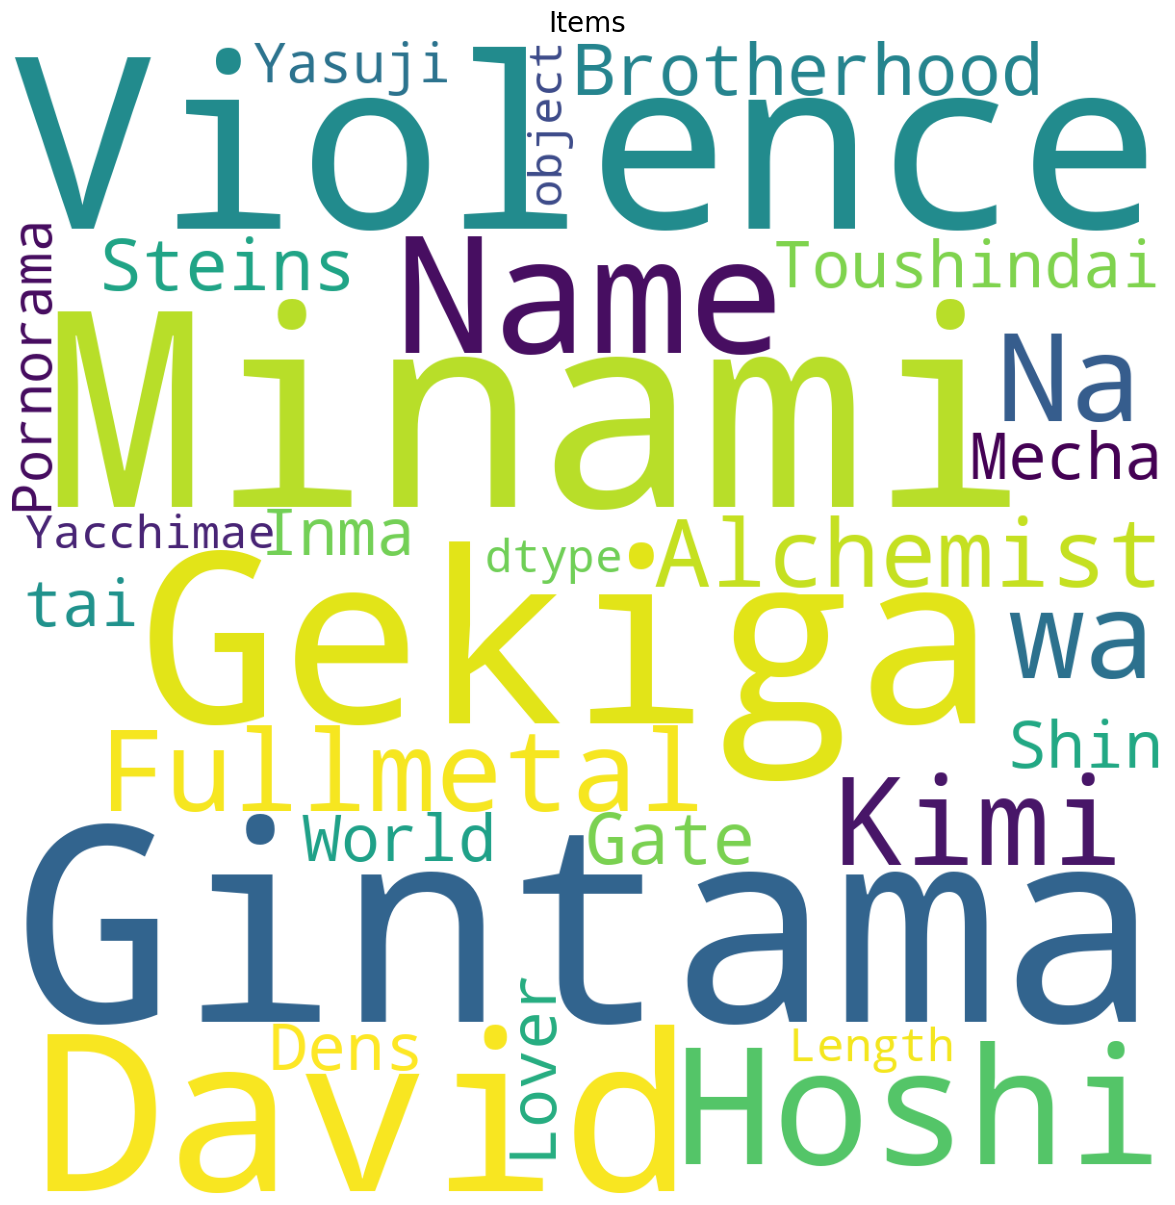

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

plt.rcParams['figure.figsize'] = (15,15)
wordcloud = WordCloud(background_color='white', width = 1200, height = 1200, max_words = 121).generate(str(df.name))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Items', fontsize = 20)
plt.show()

In [23]:
# create pivot table

In [27]:
user_anime_df = df.pivot_table(index='anime_id',columns='name',values='rating').fillna(0)
user_anime_df

name,&quot;0&quot;,"&quot;Aesop&quot; no Ohanashi yori: Ushi to Kaeru, Yokubatta Inu",&quot;Bungaku Shoujo&quot; Kyou no Oyatsu: Hatsukoi,&quot;Bungaku Shoujo&quot; Memoire,&quot;Bungaku Shoujo&quot; Movie,&quot;Eiji&quot;,&quot;Eiyuu&quot; Kaitai,.hack//G.U. Returner,.hack//G.U. Trilogy,.hack//G.U. Trilogy: Parody Mode,...,s.CRY.ed,vivi,xxxHOLiC,xxxHOLiC Kei,xxxHOLiC Movie: Manatsu no Yoru no Yume,xxxHOLiC Rou,xxxHOLiC Shunmuki,Üks Uks,ēlDLIVE,◯
anime_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34514,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34519,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34522,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
# Calculating Cosine similarity between Users
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import cosine, correlation, jaccard

In [32]:
rating.sort_values('num of ratings', ascending = False).head(10)

,rating,num of ratings
name,,
Shi Wan Ge Leng Xiaohua,6.87,2
Saru Kani Gassen,4.99,2
Otome Hime,6.36,1
Otome Juurin Yuugi: Maiden Infringement Play,6.40,1
Otome Nadeshiko Koi Techou,6.04,1
Otome Youkai Zakuro,7.60,1
Otome Youkai Zakuro Picture Drama,6.45,1
Otome wa Boku ni Koishiteru,7.18,1
Otome wa Boku ni Koishiteru Special,6.76,1


In [36]:
shi_user_rating = user_anime_df['Shi Wan Ge Leng Xiaohua']
oto_user_rating = user_anime_df['Otoshidama']
oto_user_rating.head()

,Otoshidama
anime_id,
1,0.0
5,0.0
6,0.0
7,0.0
8,0.0


In [37]:
similar_to_oto = user_anime_df.corrwith(oto_user_rating)
similar_to_shi = user_anime_df.corrwith(shi_user_rating)

In [38]:
corr_oto = pd.DataFrame(similar_to_oto,columns=['Correlation'])
corr_oto.dropna(inplace=True)
corr_oto.head()

,Correlation
name,
&quot;0&quot;,-0.000081
"&quot;Aesop&quot; no Ohanashi yori: Ushi to Kaeru, Yokubatta Inu",-0.000081
&quot;Bungaku Shoujo&quot; Kyou no Oyatsu: Hatsukoi,-0.000081
&quot;Bungaku Shoujo&quot; Memoire,-0.000081
&quot;Bungaku Shoujo&quot; Movie,-0.000081


In [41]:
corr_oto.sort_values('Correlation',ascending=False).head(10)

,Correlation
name,
Otoshidama,1.000000
Planetarium Uchuu Kyoudai: Itten no Hikari,-0.000081
Kaibutsu-kun (1980),-0.000081
Morita-san wa Mukuchi,-0.000081
Joshikousei: Girl&#039;s High,-0.000081
Hellsing: Psalm of Darkness,-0.000081
Beast Wars Neo,-0.000081
Dog Days&#039;&#039;,-0.000081
Hashire! Shiroi Ookami,-0.000081


In [43]:
corr_oto = corr_oto.join(rating['rating'])
corr_oto.head()

,Correlation,rating
name,,
&quot;0&quot;,-0.000081,5.06
"&quot;Aesop&quot; no Ohanashi yori: Ushi to Kaeru, Yokubatta Inu",-0.000081,5.00
&quot;Bungaku Shoujo&quot; Kyou no Oyatsu: Hatsukoi,-0.000081,7.06
&quot;Bungaku Shoujo&quot; Memoire,-0.000081,7.54
&quot;Bungaku Shoujo&quot; Movie,-0.000081,7.63


In [45]:
corr_oto[corr_oto['rating']>5].sort_values('Correlation',ascending=False).head()

,Correlation,rating
name,,
Kaibutsu-kun (1980),-0.000081,6.79
Planetarium Uchuu Kyoudai: Itten no Hikari,-0.000081,6.79
Joshikousei: Girl&#039;s High,-0.000081,6.69
Hellsing: Psalm of Darkness,-0.000081,7.16
Beast Wars Neo,-0.000081,6.69


In [46]:
corr_shi = pd.DataFrame(similar_to_shi,columns=['Correlation'])
corr_shi.dropna(inplace=True)
corr_shi = corr_shi.join(rating['num of ratings'])
corr_shi[corr_shi['num of ratings']>4].sort_values('Correlation',ascending=False).head()

,Correlation,num of ratings
name,,


In [47]:
user_anime_df.head()

name,&quot;0&quot;,"&quot;Aesop&quot; no Ohanashi yori: Ushi to Kaeru, Yokubatta Inu",&quot;Bungaku Shoujo&quot; Kyou no Oyatsu: Hatsukoi,&quot;Bungaku Shoujo&quot; Memoire,&quot;Bungaku Shoujo&quot; Movie,&quot;Eiji&quot;,&quot;Eiyuu&quot; Kaitai,.hack//G.U. Returner,.hack//G.U. Trilogy,.hack//G.U. Trilogy: Parody Mode,...,s.CRY.ed,vivi,xxxHOLiC,xxxHOLiC Kei,xxxHOLiC Movie: Manatsu no Yoru no Yume,xxxHOLiC Rou,xxxHOLiC Shunmuki,Üks Uks,ēlDLIVE,◯
anime_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
#Cosine Similarity between Users

In [49]:
# Calculating Cosine Similarity between Users
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import cosine, correlation, jaccard
user_sim = 1 - pairwise_distances(user_anime_df.values, metric = 'cosine')
user_sim[user_sim < 0.5] = 0
user_sim

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [50]:
# Store the results in a dataframe
user_sim_df = pd.DataFrame(user_sim)
user_sim_df

,0,1,2,3,4,5,6,7,8,9,...,12284,12285,12286,12287,12288,12289,12290,12291,12292,12293
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12289,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
12290,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
12291,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12292,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [51]:
user_sim_df.iloc[:5,:5]

,0,1,2,3,4
0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,1.0


In [52]:
import numpy as np
np.fill_diagonal(user_sim, 0)
user_sim_df.iloc[0:5,0:5]

,0,1,2,3,4
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0


In [53]:
# Set the index and columns name to user Ids
user_sim_df.index = list(user_anime_df.index)
user_sim_df.columns = list(user_anime_df.index)
user_sim_df

,1,5,6,7,8,15,16,17,18,19,...,34498,34501,34502,34503,34506,34514,34519,34522,34525,34527
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34514,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34519,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34522,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34525,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
user_id_eight = user_sim_df.sort_values([], ascending=False).head(100)
user_id_eight

,1,5,6,7,8,15,16,17,18,19,...,34498,34501,34502,34503,34506,34514,34519,34522,34525,34527
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
119,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
df[(df['anime_id']==8)  | (df['anime_id']==14)]

,anime_id,name,genre,type,episodes,rating,members
3159,8,Beet the Vandel Buster,"Adventure, Fantasy, Shounen, Supernatural",TV,52,7.06,9848


In [58]:
user_sim_df.idxmax(axis=1)

,0
1,1
5,1
6,1
7,1
8,1
...,...
34514,1
34519,1
34522,1
34525,1


In [59]:
# Vectorize 'genre' for similarity computaion
vectorizer = CountVectorizer(tokenizer=lambda x: x.split(', '))
genre_matrix = vectorizer.fit_transform(df['genre'])

# Normalize ratings if necessary
#df['rating'] = df['rating']  / df['rating'].max()

In [66]:
def give_reco(anime_id):
  tem = list(user_sim_df.sort_values([anime_id],ascending=False).head(100).index)
  #print('similar customer ids:',tem)
  movie_list=[]
  for i in tem:
    movie_list.extend(df[df['anime_id']==i]['name'])
  #print('common movies within customer', movie_list)
  return set(movie_list)-set(df[df['anime_id']==anime_id]['name'])

In [67]:
re=give_reco(32281)
re

{'.hack//Sign',
 'Aa! Megami-sama!',
 'Aa! Megami-sama! (TV)',
 'After War Gundam X',
 'Ai Yori Aoshi',
 'Air',
 'Aishiteruze Baby★★',
 'Akazukin Chacha',
 'Akira',
 'Ao no Exorcist OVA',
 'Appleseed (Movie)',
 'Arc the Lad',
 'Avenger',
 'Ayashi no Ceres',
 'Azumanga Daioh',
 'Bakuretsu Tenshi',
 'Basilisk: Kouga Ninpou Chou',
 'Beck',
 'Beet the Vandel Buster',
 'Berserk',
 'Black Cat',
 'Blue Gender',
 'Boys Be...',
 'Chobits',
 'Chou Henshin Cosprayers',
 'Chrno Crusade',
 'Chuuka Ichiban!',
 'Cluster Edge',
 'Code Geass: Fukkatsu no Lelouch',
 'Corrector Yui',
 'Cowboy Bebop',
 'Cowboy Bebop: Tengoku no Tobira',
 'D.C.: Da Capo',
 'D.N.Angel',
 'DearS',
 'Detective Conan Movie 21: Deep Red Love Letter',
 'El Hazard 2: The Magnificent World',
 'El Hazard: The Alternative World',
 'El Hazard: The Magnificent World',
 'El Hazard: The Wanderers',
 'Final Approach',
 'Fruits Basket',
 'Full Metal Panic!',
 'Full Metal Panic! The Second Raid',
 'Full Metal Panic? Fumoffu',
 'Full Moon w

In [68]:
# Different Threshold values

In [69]:
def get_recommendations(anime_id, threshold):
  #find the index of the anime with the given ID
  idx = df[df['anime_id'] == anime_id].index[0]

  # Compute cosine similarity matrix (should ideally be computed once, outside the function for performance)
  cosine_sim = cosine_similarity(genre_matrix)

  #Get similarity scores for the given anime
  sim_scores = list(enumerate(cosine_sim[idx]))

  # Filter scores by threshold and exclude the anime itself
  sim_scores = [i for i in sim_scores if i[1] >= threshold and i[0] != idx]

  # sort by similarity score (highest first)
  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

  # Get indices of the recommended anime
  anime_indices = [i[0] for i in sim_scores]

  # Return the title of the recommended anime
  return df.iloc[anime_indices][['anime_id', 'name', 'genre', 'rating']]

In [70]:
# Test the recommendation system for different thresholds
# Example list of thresholds to test
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
for threshold in thresholds:
    print(f"\nRecommendations for threshold {threshold}:")
    recommendations = get_recommendations(anime_id=32281, threshold=threshold)
    print(recommendations)




Recommendations for threshold 0.1:
       anime_id                                               name  \
5805        547                        Wind: A Breath of Heart OVA   
6394        546                       Wind: A Breath of Heart (TV)   
1111      14669              Aura: Maryuuin Kouga Saigo no Tatakai   
208       28725                      Kokoro ga Sakebitagatterunda.   
504        6351  Clannad: After Story - Mou Hitotsu no Sekai, K...   
...         ...                                                ...   
5479        159                               Boukyaku no Senritsu   
10108      5997                        Sabu to Ichi Torimono Hikae   
10696     30029                  Video Ehonkan Sekai Meisaku Douwa   
4230       1136                                          Betterman   
4432        808                              Bakuretsu Hunters OVA   

                                                   genre  rating  
5805                Drama, Romance, School, Supernatural

In [71]:
'''Threshold = 0.1:
The list is quite extensive with over 4,000 entries. Recommendations include a diverse range of genres and anime IDs, showing many options with a broad range of similarity scores.to the input preferences.
Threshold = 0.2:
The list narrows slightly to about 4,200 entries. Still covers a wide array of genres but begins to focus more on the higher similarity scores.
Threshold = 0.3:
The list reduces further to around 1,925 entries. Recommendations are more focused, with higher similarity scores and more specific genres.
Threshold = 0.4:
The list continues to shrink to approximately 1,218 entries. Recommendations are more refined, focusing on higher similarity matches.
Threshold = 0.5:
The list reduces to 829 entries. The recommendations are more concentrated, with more specific anime and higher similarity ratings.
Threshold = 0.6:
The list is further reduced to 210 entries. Recommendations are quite specific, with high similarity and more focused genres.
Threshold = 0.7:
The list has 119 entries. This list is highly focused, with very similar recommendations based on high thresholds.
Threshold = 0.8:
The list includes 36 entries. Recommendations are very precise with high similarity and targeted genres.
Threshold = 0.9:
The list is very concise with only 2 entries. The recommendations are highly specific, offering very close matches to the input preferences.'''

'Threshold = 0.1:\nThe list is quite extensive with over 4,000 entries. Recommendations include a diverse range of genres and anime IDs, showing many options with a broad range of similarity scores.to the input preferences.\nThreshold = 0.2:\nThe list narrows slightly to about 4,200 entries. Still covers a wide array of genres but begins to focus more on the higher similarity scores.\nThreshold = 0.3:\nThe list reduces further to around 1,925 entries. Recommendations are more focused, with higher similarity scores and more specific genres.\nThreshold = 0.4:\nThe list continues to shrink to approximately 1,218 entries. Recommendations are more refined, focusing on higher similarity matches.\nThreshold = 0.5:\nThe list reduces to 829 entries. The recommendations are more concentrated, with more specific anime and higher similarity ratings.\nThreshold = 0.6:\nThe list is further reduced to 210 entries. Recommendations are quite specific, with high similarity and more focused genres.\nThre

In [72]:
'''Interview Qusetions
1 User-based vs. Item-based Collaborative Filtering:
User-based filtering recommends items to a user based on the preferences of similar users. It relies on identifying user-user similarity. Item-based filtering recommends items that are similar to those the user has previously liked or rated. It computes item-item similarity.

2 Collaborative Filtering:
Collaborative filtering is a recommendation approach that makes automatic predictions about a user's interests by collecting preferences from many users. It works by finding patterns of interests shared between users or items. Two types: User-based: Users with similar preferences to the active user. Item-based: Items similar to the ones the active user liked or rated highly.'''

"Interview Qusetions\n1 User-based vs. Item-based Collaborative Filtering:\nUser-based filtering recommends items to a user based on the preferences of similar users. It relies on identifying user-user similarity. Item-based filtering recommends items that are similar to those the user has previously liked or rated. It computes item-item similarity.\n\n2 Collaborative Filtering:\nCollaborative filtering is a recommendation approach that makes automatic predictions about a user's interests by collecting preferences from many users. It works by finding patterns of interests shared between users or items. Two types: User-based: Users with similar preferences to the active user. Item-based: Items similar to the ones the active user liked or rated highly."